In [3]:
!pip install pennylane

PyTorch will use device: cpu

QUANTUM NEURAL NETWORK PIPELINE (26-CLASS)

LOADING DATA FOR 26-CLASS PROBLEM
Loaded data with shape: (303481, 6)
Using 5 columns as features.
Using original 26 class labels.

Balancing dataset...
Balancing all 26 classes to 1000 samples each.

DATASET SUMMARY
Number of features (qubits): 5
Total balanced samples: 26000
Training/Validation set: 20800 samples
Test set: 5200 samples

Configuration:
  - Classes: 26 (AESCrypt, Cerber, Cerber-largefiles, Cerber-w10dirs...)
  - Quantum circuit: 5 qubits, 3 layers

STARTING 5-FOLD CROSS-VALIDATION

Fold 1/5:

✅ Using CPU-accelerated quantum simulator (lightning.qubit)
  Epoch 5/25: Loss=2.2417, Train Acc=0.3357, Val Acc=0.4281
  Epoch 10/25: Loss=2.1224, Train Acc=0.3685, Val Acc=0.4757
  Epoch 15/25: Loss=2.0682, Train Acc=0.3823, Val Acc=0.4846
  Epoch 20/25: Loss=2.0351, Train Acc=0.3894, Val Acc=0.4841
  Epoch 25/25: Loss=2.0101, Train Acc=0.3957, Val Acc=0.4952
  Fold 1 Validation Accuracy: 0.4952

Fold 2/5:

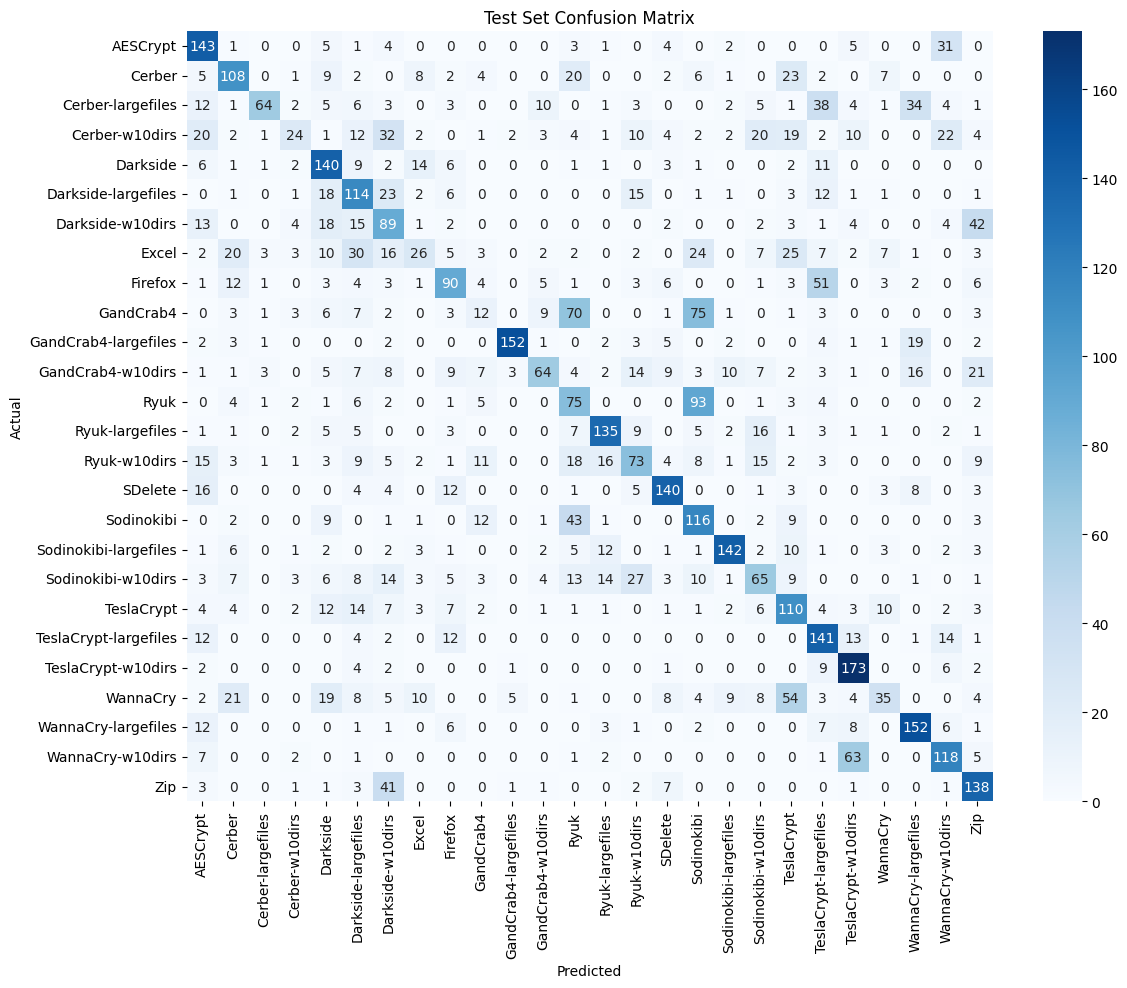

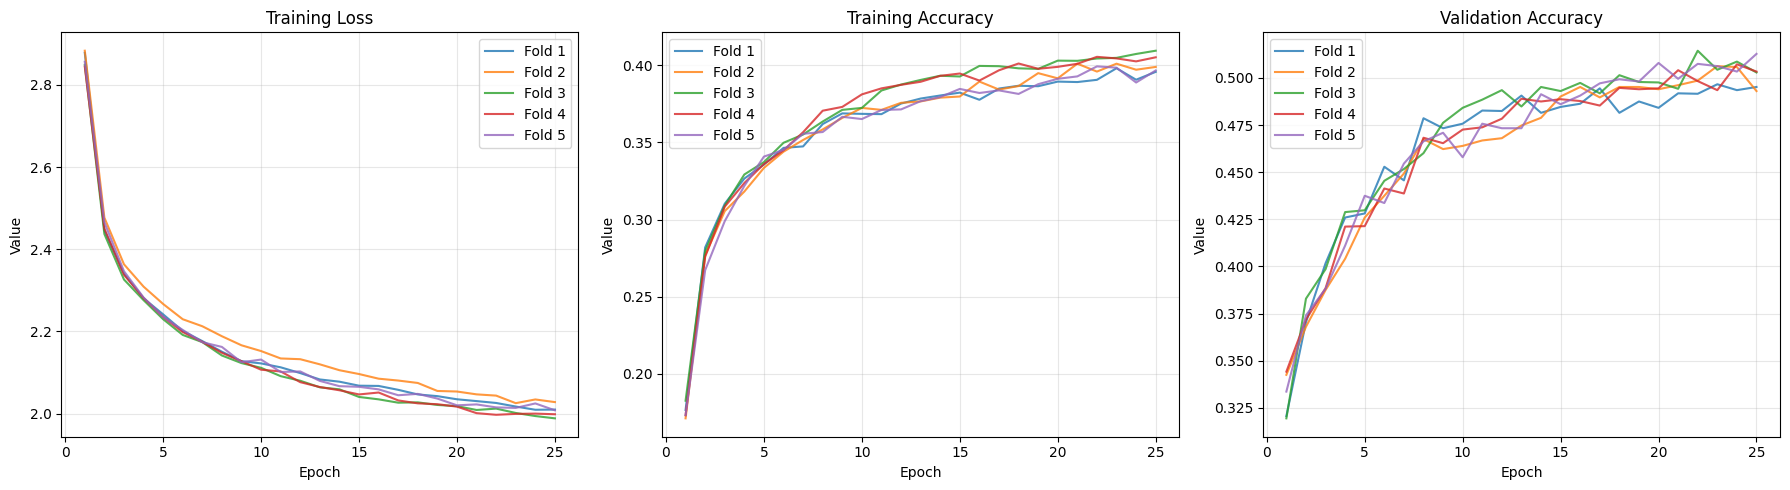



Training pipeline completed successfully!


In [5]:
import torch
import torch.nn as nn
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- Global Device Selection ---
# Force the script to run on the CPU
device = torch.device("cpu")
print(f"PyTorch will use device: {device}")


# --- Classification Setup ---
CLASS_CONFIG = {
    26: {
        "AESCrypt": 0, "Cerber": 1, "Cerber-largefiles": 2,
        "Cerber-w10dirs": 3, "Darkside": 4, "Darkside-largefiles": 5,
        "Darkside-w10dirs": 6, "Excel": 7, "Firefox": 8,
        "GandCrab4": 9, "GandCrab4-largefiles": 10,
        "GandCrab4-w10dirs": 11, "Ryuk": 12, "Ryuk-largefiles": 13,
        "Ryuk-w10dirs": 14, "SDelete": 15, "Sodinokibi": 16,
        "Sodinokibi-largefiles": 17, "Sodinokibi-w10dirs": 18,
        "TeslaCrypt": 19, "TeslaCrypt-largefiles": 20,
        "TeslaCrypt-w10dirs": 21, "WannaCry": 22,
        "WannaCry-largefiles": 23, "WannaCry-w10dirs": 24, "Zip": 25
    },
    12: {
        "AESCrypt": 0, "Cerber": 1, "Darkside": 2,
        "Excel": 3, "Firefox": 4, "GandCrab4": 5,
        "Ryuk": 6, "SDelete": 7, "Sodinokibi": 8,
        "TeslaCrypt": 9, "WannaCry": 10, "Zip": 11
    },
    2: { "Benign": 0, "Ransomware": 1 }
}
BENIGN_CLASS_IDS_26 = {0, 7, 8, 15, 25}

# --- QNN Model Definition ---
class QNN(nn.Module):
    """Quantum Neural Network model with a classical post-processing layer."""
    def __init__(self, n_qubits, n_layers, n_classes=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # --- Set to CPU-only simulator ---
        self.dev = qml.device("lightning.qubit", wires=n_qubits)
        print("\n✅ Using CPU-accelerated quantum simulator (lightning.qubit)")


        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def circuit(inputs, weights):
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(inputs[i], wires=i)
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RY(weights[l, i, 0], wires=i)
                    qml.RZ(weights[l, i, 1], wires=i)
                    qml.RX(weights[l, i, 2], wires=i)
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit = circuit
        
        weight_shape = (n_layers, n_qubits, 3)
        self.weights = nn.Parameter(0.01 * torch.randn(weight_shape))
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        # Process each sample in the batch through the quantum circuit using a loop.
        list_of_outputs = [self.circuit(x_i, self.weights) for x_i in x]
        
        # Convert the resulting list of lists into a single 2D tensor.
        quantum_features = torch.tensor(list_of_outputs, dtype=torch.float32, device=x.device)
        
        return self.classifier(quantum_features)

# --- Data Loading and Transformation ---
def load_data_from_npy(file_path: str, test_ratio: float, num_classes: int, max_samples_per_class: int = None):
    """Loads and processes data for 2, 12, or 26-class classification."""
    print("\n" + "="*50)
    print(f"LOADING DATA FOR {num_classes}-CLASS PROBLEM")
    print("="*50)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path)
    X = data[:, :-1]
    y = data[:, -1].astype(int)
    print(f"Loaded data with shape: {data.shape}")
    print(f"Using {X.shape[1]} columns as features.")

    # --- Label Transformation ---
    y_processed = None
    if num_classes == 2:
        is_benign_mask = np.isin(y, list(BENIGN_CLASS_IDS_26))
        y_processed = (~is_benign_mask).astype(int)
        print("Labels transformed to binary (0: Benign, 1: Ransomware)")
    elif num_classes == 12:
        id_to_name_26 = {v: k for k, v in CLASS_CONFIG[26].items()}
        y_processed = np.array([
            CLASS_CONFIG[12][id_to_name_26[label].split('-')[0]] for label in y
        ])
        print("Labels mapped from 26 classes to 12 families.")
    elif num_classes == 26:
        y_processed = y
        print("Using original 26 class labels.")
    else:
        raise ValueError("`num_classes` must be 2, 12, or 26.")

    # --- Multi-class Balancing with Sample Limit ---
    print("\nBalancing dataset...")
    unique, counts = np.unique(y_processed, return_counts=True)
    min_samples = np.min(counts)
    
    # Use the smaller of the specified max samples or the available minimum
    balance_to = min(min_samples, max_samples_per_class) if max_samples_per_class else min_samples
    
    print(f"Balancing all {len(unique)} classes to {balance_to} samples each.")
    
    balanced_indices = []
    for label in unique:
        indices = np.where(y_processed == label)[0]
        chosen_indices = np.random.choice(indices, balance_to, replace=False)
        balanced_indices.append(chosen_indices)
    
    balanced_indices = np.concatenate(balanced_indices)
    np.random.shuffle(balanced_indices)
    
    X_balanced = X[balanced_indices]
    y_balanced = y_processed[balanced_indices]

    # --- Splitting Data ---
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_balanced, y_balanced, test_size=test_ratio, random_state=42, stratify=y_balanced
    )
    
    print("\n" + "="*50)
    print("DATASET SUMMARY")
    print("="*50)
    print(f"Number of features (qubits): {X_train_val.shape[1]}")
    print(f"Total balanced samples: {len(X_balanced)}")
    print(f"Training/Validation set: {len(X_train_val)} samples")
    print(f"Test set: {len(X_test)} samples")

    return X_train_val, y_train_val, X_test, y_test, X_train_val.shape[1]

def evaluate_model(model, X, y, batch_size=16):
    model.eval()
    dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            # Move data to the selected device (CPU)
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def train_single_fold(X_train, y_train, X_val, y_val, n_qubits, n_classes, n_layers=3, 
                       epochs=50, batch_size=16, lr=0.001, verbose=True):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_train_quantum = np.tanh(X_train_scaled) * np.pi
    X_val_quantum = np.tanh(X_val_scaled) * np.pi
    
    train_dataset = TensorDataset(torch.FloatTensor(X_train_quantum), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Generalized class weight calculation and move to device
    class_counts = np.bincount(y_train)
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = class_weights / class_weights.sum() * n_classes
    class_weights = class_weights.to(device)
    
    model = QNN(n_qubits=n_qubits, n_layers=n_layers, n_classes=n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_preds, train_labels = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_preds, val_labels = evaluate_model(model, X_val_quantum, y_val, batch_size)
        val_acc = accuracy_score(val_labels, val_preds)
        
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    
    return model, scaler, history

def cross_validate_qnn(X, y, n_qubits, n_classes, n_folds=5, n_layers=3, epochs=50, batch_size=16, lr=0.001):
    print("\n" + "="*50)
    print(f"STARTING {n_folds}-FOLD CROSS-VALIDATION")
    print("="*50)
    
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []
    all_histories = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\nFold {fold}/{n_folds}:")
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model, scaler, history = train_single_fold(
            X_train, y_train, X_val, y_val, n_qubits, n_classes,
            n_layers=n_layers, epochs=epochs, batch_size=batch_size, lr=lr
        )
        val_preds, val_labels = evaluate_model(model, np.tanh(scaler.transform(X_val)) * np.pi, y_val, batch_size)
        val_acc = accuracy_score(val_labels, val_preds)
        
        fold_results.append({'fold': fold, 'val_accuracy': val_acc, 'model': model, 'scaler': scaler})
        all_histories.append(history)
        print(f"  Fold {fold} Validation Accuracy: {val_acc:.4f}")
    
    avg_accuracy = np.mean([r['val_accuracy'] for r in fold_results])
    print("\n" + "="*50)
    print("CROSS-VALIDATION RESULTS")
    print("="*50)
    print(f"Average Validation Accuracy: {avg_accuracy:.4f}")
    return fold_results, all_histories

def evaluate_on_test_set(fold_results, X_test, y_test, class_names, batch_size=16):
    print("\n" + "="*50)
    print("FINAL EVALUATION ON UNSEEN TEST SET")
    print("="*50)
    
    best_fold = max(fold_results, key=lambda x: x['val_accuracy'])
    best_model = best_fold['model']
    best_scaler = best_fold['scaler']
    
    print(f"Using best model from Fold {best_fold['fold']} (Val Acc: {best_fold['val_accuracy']:.4f})")
    
    X_test_quantum = np.tanh(best_scaler.transform(X_test)) * np.pi
    test_preds, test_labels = evaluate_model(best_model, X_test_quantum, y_test, batch_size)
    test_acc = accuracy_score(test_labels, test_preds)
    
    print(f"\nTest Set Accuracy: {test_acc:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=class_names, digits=4, zero_division=0))
    
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(max(6, len(class_names)//2), max(5, len(class_names)//2.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Test Set Confusion Matrix')
    plt.savefig('qnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()

def plot_training_history(all_histories):
    try:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for i, history in enumerate(all_histories):
            axes[0].plot(range(1, len(history['train_loss']) + 1), history['train_loss'], alpha=0.8, label=f'Fold {i+1}')
            axes[1].plot(range(1, len(history['train_acc']) + 1), history['train_acc'], alpha=0.8, label=f'Fold {i+1}')
            axes[2].plot(range(1, len(history['val_acc']) + 1), history['val_acc'], alpha=0.8, label=f'Fold {i+1}')
        
        axes[0].set_title('Training Loss'); axes[1].set_title('Training Accuracy'); axes[2].set_title('Validation Accuracy')
        for ax in axes:
            ax.set_xlabel('Epoch'); ax.set_ylabel('Value'); ax.legend(); ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('qnn_training_history.png', dpi=100, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not create plots: {e}")

def main_training_pipeline(npy_file_path: str, num_classes: int, n_folds: int, 
                           n_layers: int, epochs: int, batch_size: int, lr: float,
                           max_samples_per_class: int = None):
    print("\n" + "="*60)
    print(f"QUANTUM NEURAL NETWORK PIPELINE ({num_classes}-CLASS)")
    print("="*60)
    
    try:
        X_train_val, y_train_val, X_test, y_test, n_qubits = load_data_from_npy(
            file_path=npy_file_path, test_ratio=0.2, num_classes=num_classes,
            max_samples_per_class=max_samples_per_class
        )
        
        class_names = list(CLASS_CONFIG[num_classes].keys())
        
        print(f"\nConfiguration:")
        print(f"  - Classes: {num_classes} ({', '.join(class_names[:4])}...)")
        print(f"  - Quantum circuit: {n_qubits} qubits, {n_layers} layers")
        
        fold_results, all_histories = cross_validate_qnn(
            X_train_val, y_train_val, n_qubits, num_classes, n_folds,
            n_layers, epochs, batch_size, lr
        )
        
        if len(X_test) > 0:
            evaluate_on_test_set(fold_results, X_test, y_test, class_names, batch_size)
        
        plot_training_history(all_histories)
        
        best_fold = max(fold_results, key=lambda x: x['val_accuracy'])
        return best_fold['model']
        
    except Exception as e:
        print(f"\nAn error occurred: {e}")
        import traceback
        traceback.print_exc()
        return None

# --- Main Execution ---
if __name__ == "__main__":
    # --- CONFIGURATION ---
    # Choose the number of classes: 2, 12, or 26
    NUM_CLASSES = 26
    
    # Set a sample limit for faster testing, or None to use all available data
    # A value of 1000 will make the script run in a few minutes.
    MAX_SAMPLES_PER_CLASS = 1000
    
    # This dictionary maps your choice of classes to the correct Kaggle file path
    KAGGLE_FILE_PATHS = {
        2: "/kaggle/input/ransap-feature-extracted-ssd-2class/RANSAP_win7-120gb-ssd_2CLASS.npy",
        12: "/kaggle/input/ransap-feature-extracted-ssd-12class/RANSAP_win7-120gb-ssd_12CLASS.npy",
        26: "/kaggle/input/final-feature-extracted-ransap/RANSAP_win7-120gb-ssd_26CLASS.npy"
    }
    
    # Select the correct file path based on the number of classes
    NPY_FILE = KAGGLE_FILE_PATHS[NUM_CLASSES]
    
    if not os.path.exists(NPY_FILE):
        print(f"FATAL: The file was not found -> '{NPY_FILE}'")
    else:
        model = main_training_pipeline(
            npy_file_path=NPY_FILE,
            num_classes=NUM_CLASSES,
            n_folds=5,
            n_layers=3,
            epochs=25,
            batch_size=16,
            lr=0.001,
            max_samples_per_class=MAX_SAMPLES_PER_CLASS
        )
        if model:
            print("\n\nTraining pipeline completed successfully!")

